In [5]:
import os
# os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
# Helpful statement for debugging, prints the thing entered as x and the output, i.e.,
# debugPrint(1+1) will output '1+1 [int] = 2'
%matplotlib widget
import inspect
import re
def debugPrint(x):
    frame = inspect.currentframe().f_back
    s = inspect.getframeinfo(frame).code_context[0]
    r = re.search(r"\((.*)\)", s).group(1)
    print("{} [{}] = {}".format(r,type(x).__name__, x))
    
    
import os, sys
import torch
import numpy as np

# Warp-based Radius Search Implementation
import warp as wp

# Initialize Warp
wp.init()

from sphWarpCore.math import *
from sphWarpCore.util import castTorchToWarp, castWarpToTorch, castTorchToWarpAsBuiltins
from sphWarpCore.radiusSearch.wp_radius_small import warp_radius_search_small
from sphWarpCore.radius import *
from warp.types import vector
from sphWarpCore.autograd import warpWrapper, WarpFunctionWrapper
from sphWarpCore.ops import *
import matplotlib.pyplot as plt

wp.config.verify_autograd_array_access = True
wp.config.verbose = True


Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [6]:
@torch.jit.script
def volumeToSupport(volume : float, targetNeighbors : int, dim : int):
    """
    Calculates the support radius based on the given volume, target number of neighbors, and dimension.

    Parameters:
    volume (float): The volume of the support region.
    targetNeighbors (int): The desired number of neighbors.
    dim (int): The dimension of the space.

    Returns:
    torch.Tensor: The support radius.
    """
    if dim == 1:
        # N_h = 2 h / v -> h = N_h * v / 2
        return targetNeighbors * volume / 2
    elif dim == 2:
        # N_h = \pi h^2 / v -> h = \sqrt{N_h * v / \pi}
        return torch.sqrt(targetNeighbors * volume / np.pi)
    else:
        # N_h = 4/3 \pi h^3 / v -> h = \sqrt[3]{N_h * v / \pi * 3/4}
        return torch.pow(targetNeighbors * volume / np.pi * 3 /4, 1/3)
    
def generateNeighborTestData(nx, targetNumNeighbors, dim, periodic, device):


    minDomain = torch.tensor([-1] * dim, dtype = torch.float32, device = device)
    maxDomain = torch.tensor([ 1] * dim, dtype = torch.float32, device = device)
    periodicity = torch.tensor([periodic] * dim, device = device, dtype = torch.bool)

    extent = maxDomain - minDomain
    shortExtent = torch.min(extent, dim = 0)[0].item()
    dx = (shortExtent / nx)
    ny = int(1 // dx)
    h = volumeToSupport(dx**dim, targetNumNeighbors, dim)
    dy = dx / 1.5
    ny = int(1 // dy)

    positions = []
    for d in range(dim):
        positions.append(torch.linspace(minDomain[d] + dx / 2, maxDomain[d] - dx / 2, int((extent[d] - dx) / dx) + 1, device = device))
    grid = torch.meshgrid(*positions, indexing = 'xy')
    
    positions = torch.stack(grid, dim = -1).reshape(-1,dim).to(device)
    supports = torch.ones(positions.shape[0], device = device) * h
    
    domain = DomainDescription(minDomain, maxDomain, periodicity, dim)
    
    return positions, supports, positions.shape[0], domain, dx

In [7]:
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# if platform.system() == 'Darwin':
    # device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
device = torch.device('cpu')
device = torch.device('cuda')
targetNumNeighbors = 50
nx = 32
dim = 2
numParticles = nx**dim

def getNextPrime(n):
    # Compute the next larger prime number greater than n
    # used primarily to set the hash map length to a prime number for better distribution of particles in the hash map
    
    def is_prime(num):
        if num <= 1:
            return False
        for i in range(2, int(num**0.5) + 1):
            if num % i == 0:
                return False
        return True
    
    prime = n + 1
    while True:
        if is_prime(prime):
            return prime
        prime += 1

# hashMapLength = getNextPrime(numParticles)
# periodic = False
# x, h, numParticles, domain, dx = generateNeighborTestData(nx, targetNumNeighbors, dim, False, device)

# pointCloud = PointCloud(x, h)
# queryPositions = pointCloud.positions
# querySupports = pointCloud.supports
# referencePositions = pointCloud.positions
# referenceSupports = pointCloud.supports
# mode = 'gather'

# offset = 0

In [8]:

device = torch.device(device)
numParticles = nx**dim
hashMapLength = getNextPrime(numParticles)
periodic = False
x, h, numParticles, domain, dx = generateNeighborTestData(nx, targetNumNeighbors, dim, False, device)

x += torch.randn_like(x) * dx * 0.1

pointCloud = PointCloud(x, h)
queryPositions = pointCloud.positions.contiguous()
querySupports = pointCloud.supports
referencePositions = pointCloud.positions.contiguous()
referenceSupports = pointCloud.supports

queryMasses = torch.ones(x.shape[0], device = x.device) * dx**dim
referenceMasses = torch.ones(x.shape[0], device = x.device) * dx**dim

mode = 'gather'

In [9]:
import diffSPH
from diffSPH.sampling import ParticleSet
from diffSPH.schemes.states.common import BasicState
from diffSPH.modules.density import computeDensity
from diffSPH.neighborhood import PointCloud, DomainDescription, buildNeighborhood, filterNeighborhood, coo_to_csrsc, coo_to_csr
from diffSPH.kernels import *
from diffSPH.neighborhood import evaluateNeighborhood, SupportScheme, computeNeighborhoodStates
from diffSPH.enums import Operation, SupportScheme, GradientMode, LaplacianMode
from diffSPH.operations import SPHOperation
from sphWarpCore.ops import sphOperation_warp
from sphWarpCore.enumTypes import *
from sphWarpCore.operations.wp_covariance import computeSPHCovariance_warpBackend
from diffSPH.math import pinv2x2
from diffSPH.modules.renorm import computeCovarianceMatrices
from diffSPH.operations import KernelCorrectionScheme
from diffSPH.modules.adaptiveSmoothing import *
import diffSPH
from diffSPH.sampling import ParticleSet
from diffSPH.schemes.states.common import BasicState
from diffSPH.modules.density import computeDensity
from diffSPH.neighborhood import PointCloud, DomainDescription, buildNeighborhood, filterNeighborhood, coo_to_csrsc, coo_to_csr
from diffSPH.kernels import *
from diffSPH.neighborhood import evaluateNeighborhood, SupportScheme, computeNeighborhoodStates
from diffSPH.enums import Operation, SupportScheme, GradientMode, LaplacianMode
from diffSPH.operations import SPHOperation





In [21]:

def prepData(
    nx, targetNumNeighbors, dim, device, warpOnly = False
):

    device = torch.device(device)
    numParticles = nx**dim
    hashMapLength = getNextPrime(numParticles)
    periodic = False
    x, h, numParticles, domain, dx = generateNeighborTestData(nx, targetNumNeighbors, dim, False, device)

    x += torch.randn_like(x) * dx * 0.1

    pointCloud = PointCloud(x, h)
    queryPositions = pointCloud.positions.contiguous()
    querySupports = pointCloud.supports
    referencePositions = pointCloud.positions.contiguous()
    referenceSupports = pointCloud.supports

    queryMasses = torch.ones(x.shape[0], device = x.device) * dx**dim
    referenceMasses = torch.ones(x.shape[0], device = x.device) * dx**dim

    mode = 'gather'

    adjacency = radiusSearchCompactHashMap(
            queryPositions, referencePositions, 
            querySupports, referenceSupports, 
            domain.periodic, domain,
            mode, hashMapLength
    )
    if warpOnly == True:
        # print("Adjacency: ", adjacency)
        return queryPositions, referencePositions, querySupports, referenceSupports, queryMasses, referenceMasses, None, None, domain, adjacency, None, None

    particles_l = ParticleSet(positions = referencePositions, supports = referenceSupports, masses = referenceMasses, densities = torch.zeros_like(referenceMasses))

    positions_t = referencePositions.clone()
    simulationState = BasicState(
        positions = positions_t,
        supports = particles_l.supports,
        masses = particles_l.masses,
        densities = particles_l.densities,        
        velocities = torch.zeros_like(referencePositions),
        kinds = torch.zeros(referencePositions.shape[0], dtype = torch.int64, device = referencePositions.device),
        materials = torch.zeros(referencePositions.shape[0], dtype = torch.int64, device = referencePositions.device),
        UIDs = torch.arange(referencePositions.shape[0], device = referencePositions.device)
    )

    # neighborhood, neighbors = evaluateNeighborhood(simulationState, domain,  KernelType.Wendland4, verletScale =1.0, mode = SupportScheme.Gather, priorNeighborhood=None, computeHessian=False, computeDkDh=False, only_j = False)
    neighborhood, sparseNeighborhood_ = buildNeighborhood(simulationState, simulationState, domain, verletScale = 1.0, mode = 'gather', priorNeighborhood=None)

    state = computeNeighborhoodStates(simulationState, sparseNeighborhood_, 'gather', KernelType.Wendland2, KernelType.Wendland2, True, True, False)

    neighborhood = state.get('noghost')

    densities = sphOperation_warp(
            queryPositions, referencePositions,
            querySupports, referenceSupports,
            queryMasses, referenceMasses,
            None, None,
            None, None,
            domain, adjacency,
            operation=WarpOperation.Density,
            kernel = KernelFunctions.Wendland2, supportMode = SupportScheme.Gather
    )

    simulationState.densities = densities
    return queryPositions, referencePositions, querySupports, referenceSupports, queryMasses, referenceMasses, densities, densities, domain, adjacency, neighborhood, simulationState


In [57]:
import time
def timeFunction(func, *args, **kwargs):
    begin = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    torch.cuda.synchronize()
    cpuBegin = time.time()
    begin.record()
    
    result = func(*args, **kwargs)
    
    end.record()
    torch.cuda.synchronize()
    cpuEnd = time.time()
    gpuTime = begin.elapsed_time(end)
    cpuTime = cpuEnd - cpuBegin
    
    return result, gpuTime, cpuTime * 1000


In [58]:
nSamples = 8

In [67]:
from tqdm.autonotebook import tqdm
def benchmark(nx, targetNumNeighbors, dim, device, nSamples, warpOnly = False):

        queryPositions, referencePositions, \
                querySupports, referenceSupports, \
                queryMasses, referenceMasses, \
                queryDensities, referenceDensities, \
                domain, adjacency, neighborhood, simulationState = prepData(nx, targetNumNeighbors, dim, device, warpOnly)

        measurements = []

        for i in tqdm(range(nSamples), desc = f"Benchmarking [warp] with {nx**dim} particles, target neighbors: {targetNumNeighbors}, dim: {dim}, device: {device}", leave=False):

                warp_result, warp_gpu_time, warp_cpu_time = timeFunction(sphOperation_warp,
                        queryPositions, referencePositions,
                        querySupports, referenceSupports,
                        queryMasses, referenceMasses,
                        None, None,
                        None, None,
                        domain, adjacency,
                        operation=WarpOperation.Density,
                        kernel = KernelFunctions.Wendland2, supportMode = SupportScheme.Gather
                )

                measurements.append({
                        'iter': i,
                        'device': device,
                        'numNeighbors': targetNumNeighbors,
                        'numParticles': nx**dim,
                        'dim': dim,
                        'nx': nx,
                        'backend': 'WarpSPH',
                        'operation': 'Density',
                        'gpuTime': warp_gpu_time,
                        'cpuTime': warp_cpu_time,
                        'minNeighbors': torch.min(adjacency.numNeighbors).item(),
                        'maxNeighbors': torch.max(adjacency.numNeighbors).item(),
                        'meanNeighbors': torch.mean(adjacency.numNeighbors.float()).item()
                })

        if warpOnly == True:
            return measurements
        for i in tqdm(range(nSamples), desc = f"Benchmarking [diffSPH] with {nx**dim} particles, target neighbors: {targetNumNeighbors}, dim: {dim}, device: {device}", leave=False):

                diffsph_result, diffsph_gpu_time, diffsph_cpu_time = timeFunction(SPHOperation,
                        simulationState,
                        quantity = None,
                        kernel = KernelType.Wendland2,
                        neighborhood = neighborhood[0],
                        kernelValues = neighborhood[1],
                        operation=Operation.Density,
                        supportScheme = SupportScheme.Gather,
                        correctionTerms= [],
                        positiveDivergence=False
                )
                measurements.append({
                        'iter': i,
                        'device': device,
                        'numNeighbors': targetNumNeighbors,
                        'numParticles': nx**dim,
                        'dim': dim,
                        'nx': nx,
                        'backend': 'DiffSPH',
                        'operation': 'Density',
                        'gpuTime': diffsph_gpu_time,
                        'cpuTime': diffsph_cpu_time,
                        'minNeighbors': torch.min(adjacency.numNeighbors).item(),
                        'maxNeighbors': torch.max(adjacency.numNeighbors).item(),
                        'meanNeighbors': torch.mean(adjacency.numNeighbors.float()).item()
                })
        return measurements

In [71]:
nxs = [16, 32, 64, 128, 256, 512, 1024, 2048]
targetNumNeighbors = 50
dims = [2]
devices = ['cuda'] if torch.cuda.is_available() else ['cpu']
devices = ['cpu']
all_measurements = []
nSamples = 16

warpOnly = True

_ = benchmark(nxs[0], targetNumNeighbors, dims[0], devices[0], nSamples , warpOnly)

for device in tqdm(devices, desc = "Devices"):
    for dim in tqdm(dims, desc = "Dimensions", leave=False):
        for nx in tqdm(nxs, desc = "Resolutions", leave=False):
            measurements = benchmark(nx, targetNumNeighbors, dim, device, nSamples, warpOnly)
            all_measurements.extend(measurements)

Benchmarking [warp] with 256 particles, target neighbors: 50, dim: 2, device: cpu:   0%|          | 0/16 [00:0…

Devices:   0%|          | 0/1 [00:00<?, ?it/s]

Dimensions:   0%|          | 0/1 [00:00<?, ?it/s]

Resolutions:   0%|          | 0/8 [00:00<?, ?it/s]

Benchmarking [warp] with 256 particles, target neighbors: 50, dim: 2, device: cpu:   0%|          | 0/16 [00:0…

...

Benchmarking [warp] with 65536 particles, target neighbors: 50, dim: 2, device: cpu:   0%|          | 0/16 [00…

Benchmarking [warp] with 262144 particles, target neighbors: 50, dim: 2, device: cpu:   0%|          | 0/16 [0…

Benchmarking [warp] with 1048576 particles, target neighbors: 50, dim: 2, device: cpu:   0%|          | 0/16 […

Benchmarking [warp] with 4194304 particles, target neighbors: 50, dim: 2, device: cpu:   0%|          | 0/16 […

KeyboardInterrupt: 

In [69]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
pdData = pd.DataFrame(all_measurements)
pdData = pdData[pdData['dim'] == 2]

display(pdData)

,iter,device,numNeighbors,numParticles,dim,nx,backend,operation,gpuTime,cpuTime,minNeighbors,maxNeighbors,meanNeighbors
0,0,cpu,50,256,2,16,WarpSPH,Density,0.714720,1.224995,16,51,39.015625
1,1,cpu,50,256,2,16,WarpSPH,Density,0.698752,0.751257,16,51,39.015625
2,2,cpu,50,256,2,16,WarpSPH,Density,0.827072,0.868320,16,51,39.015625
3,3,cpu,50,256,2,16,WarpSPH,Density,0.932928,0.990629,16,51,39.015625
4,0,cpu,50,256,2,16,DiffSPH,Density,1.901856,7.282972,16,51,39.015625
5,1,cpu,50,256,2,16,DiffSPH,Density,1.793600,2.153397,16,51,39.015625
6,2,cpu,50,256,2,16,DiffSPH,Density,4.704288,4.750013,16,51,39.015625
7,3,cpu,50,256,2,16,DiffSPH,Density,1.938208,2.108574,16,51,39.015625
8,0,cpu,50,1024,2,32,WarpSPH,Density,2.456160,3.038168,15,52,43.457031
9,1,cpu,50,1024,2,32,WarpSPH,Density,1.991296,2.143383,15,52,43.457031


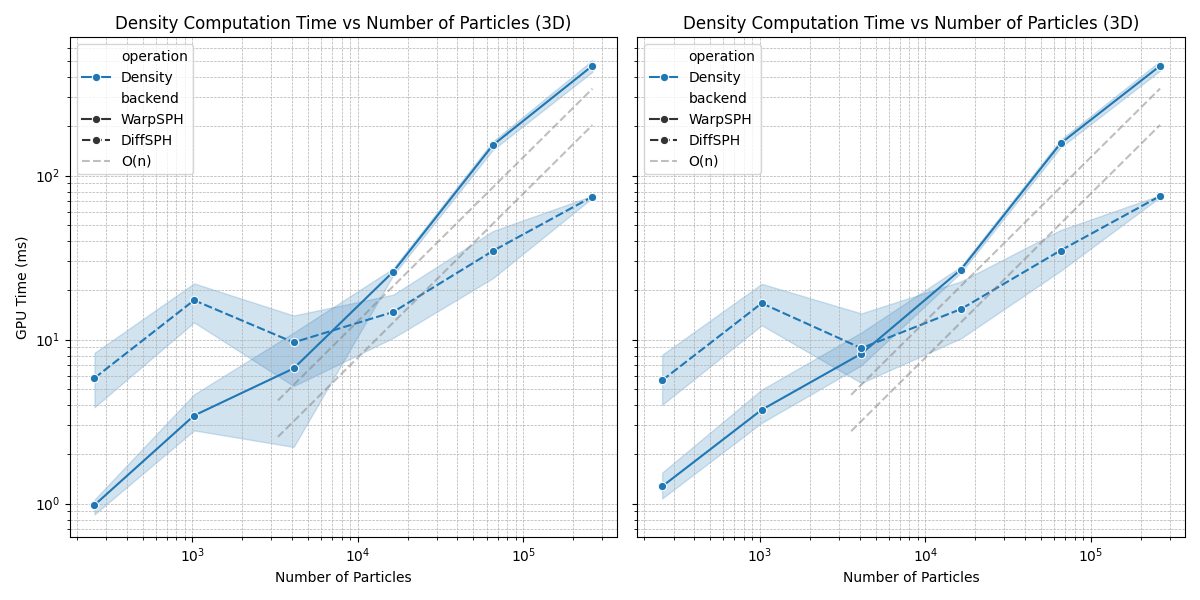

In [66]:
def add_scaling_line(ax, data, x_col, y_col, scale_factor=0.1, color='gray', linestyle='--', alpha=0.5):
    x_vals = data[x_col].unique()
    x_vals = np.sort(x_vals)
    y_mean = data.groupby(x_col)[y_col].mean()
    
    y_max = y_mean.max()
    y_min = y_mean.min()
    
    x_ref = x_vals[0]
    
    # print(f"x_vals: {x_vals}")
    # print(f"y_min: {y_min}, y_max: {y_max}")
    
    upper_scale = y_max * (1 + scale_factor)
    lower_scale = y_min * (1 + scale_factor)
    
    # now we want the line to go from [x, lower_scale] to [xmax, upper_scale] with a slope of 1 in log-log space, which means it should be a line of the form y = C * x, where C is a constant that we can determine based on the reference point (x_ref, y_ref)
    # print(f"upper_scale: {upper_scale}, lower_scale: {lower_scale}")
    y_ratio = upper_scale / lower_scale
    # print(f"y_ratio: {y_ratio}")
    x_lower = x_vals[-1] * (lower_scale / upper_scale)
    # print(f"x_lower: {x_lower}")
    ax.plot([x_lower, x_vals[-1]], [lower_scale, upper_scale], color=color, linestyle=linestyle, alpha=alpha, label='O(n)')
    
    upper_scale = y_max * (1 - scale_factor)
    lower_scale = y_min * (1 - scale_factor)
    y_ratio = upper_scale / lower_scale
    x_lower = x_vals[-1] * (lower_scale / upper_scale)
    ax.plot([x_lower, x_vals[-1]], [lower_scale, upper_scale], color=color, linestyle=linestyle, alpha=alpha)
    
scale_factor = 0.25    

fig, axis = plt.subplots(1,2, figsize = (12,6), squeeze = False, sharey = True)
import copy

plotData = copy.deepcopy(pdData)

curData =  plotData[plotData['operation'] == 'Density']

sns.lineplot(data = curData, x = 'numParticles', y = 'gpuTime', hue = 'operation', style = 'backend', ax = axis[0,0], marker = 'o')
axis[0,0].set_xscale('log')
axis[0,0].set_yscale('log')
axis[0,0].set_xlabel('Number of Particles')
axis[0,0].set_ylabel('GPU Time (ms)')
axis[0,0].set_title('Density Computation Time vs Number of Particles (3D)')
axis[0,0].grid(True, which = 'both', linestyle='--', linewidth=0.5)
add_scaling_line(axis[0, 0], curData, 'numParticles', 'gpuTime', scale_factor=scale_factor)
axis[0, 0].legend()

sns.lineplot(data = curData, x = 'numParticles', y = 'cpuTime', hue = 'operation', style = 'backend', ax = axis[0,1], marker = 'o')
axis[0,1].set_xscale('log')
axis[0,1].set_yscale('log')
axis[0,1].set_xlabel('Number of Particles')
axis[0,1].set_ylabel('CPU Time (ms)')
axis[0,1].set_title('Density Computation Time vs Number of Particles (3D)')
axis[0,1].grid(True, which = 'both', linestyle='--', linewidth=0.5)
add_scaling_line(axis[0, 1], curData, 'numParticles', 'cpuTime', scale_factor=scale_factor)
axis[0, 1].legend()


fig.tight_layout()